In [1]:
## load required packages
from dill.temp import b
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import jax
print("JAX path:", jax.__file__)

## load module
import sys

bstpp_module_dir = os.path.abspath('/Users/ctwomey/Research/WPF Illegal Dumping/project/Elena/BSTPP')
#bstpp_module_dir = os.path.abspath('/Users/ctwomey/Research/WPF Illegal Dumping/project/BSTPP')
sys.path.insert(0, bstpp_module_dir)
import bstpp

import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd
import geopandas as gpd
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns
#!pip install torch
import torch
from shapely.geometry import box
import contextily as ctx ## for basemap
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates 
import calendar
import matplotlib.ticker as ticker
from matplotlib.colors import ListedColormap
from shapely.geometry import Point ## for spatial jittering
import osmnx as ox
import shapely.geometry as geom
from scipy.stats import lomax
from collections import defaultdict
from statistics import mean, median
# from tqdm import tqdm
from tqdm.notebook import tqdm
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
from datetime import datetime


np.random.seed(999)


from bstpp.main import Hawkes_Model 
from bstpp.trigger import Temporal_Power_Law, simulate_hawkes_like_events,plot_inter_arrival_distribution

JAX path: /Users/yuxin/miniconda3/lib/python3.12/site-packages/jax/__init__.py


In [2]:
## set working directory
import os
os.chdir("/Users/yuxin/Dropbox/DDDI/Illegal-Dumping")

## Loadding shapefiles for plotting

### CBG border and Land care data

In [3]:
# load philly cbg border
pa_2023 = gpd.read_file('data/tiger/tl_2023_42_bg/tl_2023_42_bg.shp')
philly_2023 = pa_2023[pa_2023['COUNTYFP']=='101']
philly_2023 = philly_2023.to_crs(epsg=26918)

In [4]:
## load land care data
land_care = gpd.read_file('data/Land_Care/phs_landcare.geojson')

land_care['year'] = pd.to_numeric(land_care['year'], errors='coerce')

## Filter for years between 2021 and 2025
land_care_21_25= land_care[(land_care['year'] >= 2021) & (land_care['year'] <= 2025)]

land_care_21_25 = land_care_21_25.to_crs(epsg=26918)

### Land Use

In [5]:
## load land use data
land_use_current = gpd.read_file('data/Land_Use/Land_use.geojson')

## recategorize land use types
land_use_current['type'] = pd.Series(dtype='object')

# residential
land_use_current.loc[(land_use_current['c_dig2'] == 11),'type'] = "Res Low Den"
land_use_current.loc[(land_use_current['c_dig2'] == 12),'type'] = "Res Med Den"
land_use_current.loc[(land_use_current['c_dig2'] == 13),'type'] = "Res High Den"
# commercial
land_use_current.loc[
    (land_use_current['c_dig2'] == 21) | (land_use_current['c_dig2'] == 22)|(land_use_current['c_dig2'] == 23),
    'type'
] = "Commercial"
# civic 
land_use_current.loc[
    (land_use_current['c_dig2'] == 41) | (land_use_current['c_dig2'] == 61)|(land_use_current['c_dig2'] == 62)|(land_use_current['c_dig2'] == 71)|(land_use_current['c_dig2'] == 72),
    'type'
] = "Civic"
# other
land_use_current.loc[(land_use_current['c_dig2'] == 31),'type'] = "Industry"
land_use_current.loc[(land_use_current['c_dig2'] == 51),'type'] = "Transportation"
land_use_current.loc[(land_use_current['c_dig2'] == 51),'type'] = "Green ROW"
land_use_current.loc[(land_use_current['c_dig2'] == 81),'type'] = "Water"
land_use_current.loc[(land_use_current['c_dig2'] == 91),'type'] = "Vacant"
land_use_current.loc[(land_use_current['c_dig2'] == 92),'type'] = "Other"

In [6]:
## Customize color map for land use categories
use_lst = ['Res Low Den', 'Res Med Den', 'Res High Den', 'Commercial', 'Civic', 'Industry', 'Transportation', 'Green ROW', 'Water', 'Vacant', 'Other']
colors = ['#543f32', '#db4d6d', '#69821b', '#e6b422', '#5654a2','#0095d9', '#a73836', '#a8bf93','#164a84', '#b3ada0','#d3cfd9']

use_color = dict(zip(colors,use_lst))

## reset order in land_use_currect
land_use_current['type'] = pd.Categorical(land_use_current['type'], categories=use_lst, ordered=True)

land_use_current = land_use_current.to_crs(epsg=26918)

In [7]:
# ## plot land use type
# land_use_current['type'] = land_use_current['type'].astype('category')
# #cmap = 'tab20b' # set qualitatitive color map
# cmap = ListedColormap(use_color)

# fig, ax = plt.subplots(figsize=(9,9))
# land_use_current[land_use_current['year'] == 2023].plot(
#     ax=ax,
#     column='type',
#     cmap=cmap,
#     alpha=0.9,
#     legend=True,
#     legend_kwds={
#         'loc': 'center left',
#         'bbox_to_anchor': (1, 0.5),
#         'title': 'Land Use Type'
#     }
# )
# plt.title('Land Use Types')
# plt.xticks([])
# plt.yticks([])
# ax.set_frame_on(False)
# plt.savefig('output/land_use.png', dpi=500, bbox_inches='tight')
# plt.show()

### Vacant Block

In [8]:
## load data
vacant_block = gpd.read_file('data/Vacant_Block_Percent_Land.geojson')
vacant_block = vacant_block.to_crs(epsg=26918)

In [9]:
dumping_hotspot_gdf = gpd.read_file("data/PPR_BaseFiles_IllegalDumpingModel.gdb", 
                    layer='PPR_Dumping_HotSpots')
dumping_hotspot_gdf = dumping_hotspot_gdf.to_crs(epsg=26918) 
     

## Loadding illegal dumping data

### Public-accessible 311: 2014 till now

In [10]:
# ## load 2024 data
# litter_24 = gpd.read_file('data/311/2024/public_cases_fc.shp')
# ## filter data
# illegal_dumping_24 = litter_24[litter_24['service_na'] == "Illegal Dumping"]

# ## load 2023 data
# litter_23 = gpd.read_file('data/311/2023/public_cases_fc.shp')
# ## filter data
# illegal_dumping_23 = litter_23[litter_23['service_na'] == "Illegal Dumping"]

# ## load 2022 data
# litter_22 = gpd.read_file('data/311/2022/public_cases_fc.shp')
# ## filter data
# illegal_dumping_22 = litter_22[litter_22['service_na'] == "Illegal Dumping"]

# ## load 2021 data
# litter_21 = gpd.read_file('data/311/2021/public_cases_fc.shp')
# ## filter data
# illegal_dumping_21 = litter_21[litter_21['service_na'] == "Illegal Dumping"]

# ## load 2020 data: skip since COVID
# #litter_20 = gpd.read_file('data/311/2020/public_cases_fc.shp')
# ## filter data
# #illegal_dumping_20 = litter_20[litter_20['service_na'] == "Illegal Dumping"]

In [11]:
# ## concact 2021, 2022, 2023, and 2024 data
# illegal_dumping = pd.concat([
#     #illegal_dumping_20,
#     illegal_dumping_21,
#     illegal_dumping_22,
#     illegal_dumping_23,
#     illegal_dumping_24
# ])
# #illegal_dumping = illegal_dumping_23
# total_days = 365 * 4

# illegal_dumping = illegal_dumping.to_crs(epsg=26918)

In [12]:
## export to geojson
#illegal_dumping.to_file('output/illegal_dumping_21_24.geojson', driver='GeoJSON')

### 311 Data from the teams

In [ ]:
# ## loadding filtered 311 data
# illegal_dumping = gpd.read_file('output/illegal_dumping_full.geojson')

# ## filter out cases after 2024-12-31
# illegal_dumping = illegal_dumping[illegal_dumping['start_time'] <= '2025-01-01']

# ## set total days
# total_days = 365 * 4

# print(illegal_dumping.shape[0])

109815


In [7]:
illegal_dumping['department'].unique()

array(['Streets Department', 'Philly311 Contact Center',
       'Parks & Recreation'], dtype=object)

In [8]:
illegal_dumping[illegal_dumping['department']=="Parks & Recreation"].head()

,start_time,close_time,request_id,type,department,address,zipcode,status,problem_category,problem,...,material_type,material_condition,description,lat,lon,case_id,parent_case_id,media_url,year,geometry
131576,2021-03-29 09:31:00,2021-03-30 16:26:00,14027719,Grounds Maintenance,Parks & Recreation,1401 N 5TH ST,19122.0,Closed,Grounds,None,...,None,None,undefined\n\n Custom Fields: \nCustom fields:\...,39.972969,-75.144099,5001M00001gjEXH,None,https://d17aqltn7cihbm.cloudfront.net/uploads/...,2021.0,POINT (487694.893 4424766.968)
131577,2021-09-06 09:03:00,2022-01-14 13:31:00,14395035,Grounds Maintenance,Parks & Recreation,3910 CONSHOHOCKEN AVE,19131.0,Closed,Grounds,None,...,None,None,Bagged trash needs to be picked up.\n\n Custom...,40.001963,-75.208395,5001M00001lHYLi,None,https://d17aqltn7cihbm.cloudfront.net/uploads/...,2021.0,POINT (482211.993 4427995.854)
131578,2021-04-05 17:46:00,NaT,14051731,Grounds Maintenance,Parks & Recreation,600 W SPENCER AVE,19120.0,In-Progress,Grounds,Landscape,...,None,None,Custom Fields: \nCustom fields:\nLarge Crew & ...,40.044339,-75.130841,5001M00001hEzMC,None,None,2021.0,POINT (488838.677 4432686.588)
131579,2021-03-01 10:52:00,2021-05-05 17:15:00,13961203,Grounds Maintenance,Parks & Recreation,3001 E THOMPSON ST,19134.0,Closed,Grounds,None,...,None,None,"Overflowing trash cans, shredded flag, shoppin...",39.982371,-75.107108,5001M00001g2dSP,None,https://d17aqltn7cihbm.cloudfront.net/uploads/...,2021.0,POINT (490854.925 4425806.023)
131580,2021-03-28 17:19:00,2021-04-29 08:09:00,14027141,Grounds Maintenance,Parks & Recreation,3001 E ALLEGHENY AVE,19134.0,Closed,Grounds,None,...,None,None,Trash is overflowing and graffiti on boat more...,39.977998,-75.095177,5001M00001gj881,5001M00001hDE17,https://d17aqltn7cihbm.cloudfront.net/uploads/...,2021.0,POINT (491873.138 4425319.498)


In [16]:
## break down material type
# Split the categories and create a list of all categories
all_categories = illegal_dumping['material_type'].str.split(';').explode().str.strip()

# Find the unique values
unique_categories = all_categories.unique()

# Print the unique categories
print(unique_categories)

['Other' 'Mattress and Furniture' 'Mattress/Furniture'
 'Construction Material' 'Construction Materials' 'Appliances'
 "TV's and Monitors" 'TV?s and Monitors' None 'Mattress & Furniture'
 'Tires' 'Building Materials']


### 311 Data - first case within clusters

In [17]:
# # ## loadding filtered 311 data
# illegal_dumping = gpd.read_file('output/illegal_dumping_clustered.geojson')

# ## filter out cases after 2024-12-31
# #illegal_dumping = illegal_dumping[illegal_dumping['start_time'] <= '2025-01-01']

# ## set total days
# total_days = 365 * 4

## Loadding shapefiles

### Get University City's polygon

In [18]:
## downloaded from https://github.com/opendataphilly/open-geo-data/tree/master/philadelphia-neighborhoods
philly_neighbor = gpd.read_file('data/philadelphia-neighborhoods.geojson')
philly_neighbor = philly_neighbor.to_crs(26918)

## restrict to University City
univ_city = philly_neighbor[philly_neighbor['MAPNAME'] == 'University City']

In [19]:
## set buffer square
buffer_val = 300  # meters
minx, miny, maxx, maxy = univ_city.total_bounds
univ_square = geom.box(minx - buffer_val, miny - buffer_val,
                              maxx + buffer_val, maxy + buffer_val)

# Wrap into GeoDataFrame for plotting/export
univ_square_gdf = gpd.GeoDataFrame(geometry=[univ_square], crs=univ_city.crs)

In [20]:
## export to geojson
univ_square_gdf.to_file('output/univ_square_gdf.geojson', driver='GeoJSON')


In [21]:
# fig,ax = plt.subplots()
# univ_city.plot(ax=ax)
# univ_square_gdf.plot(ax= ax, edgecolor = "blue", color = "none")

In [22]:
# ## check if univ_city is all-covered by foot traffic data
# # load foor traffic data
# df_avg_geo = gpd.read_file('output/ft_avg_geo.geojson')

# ft_univ = df_avg_geo.sjoin(univ_square_gdf, predicate='intersects')

In [23]:
# ## plotting to check
# fig,ax = plt.subplots()
# univ_city.plot(ax=ax, edgecolor = "#011f5b", color = "none", linewidth=2, zorder=3)
# univ_square_gdf.plot(ax=ax, edgecolor = "blue", color = "none")
# ft_univ.plot(ax=ax, edgecolor = "red", color = "white", alpha = 0.5)

### Loadding park boundaries

In [9]:
## load philly's city map for mapping
philly_border = gpd.read_file('data/City_Limits/City_Limits.shp')
philly_border = philly_border.to_crs(epsg=26918)

## load PPR data
ppr =gpd.read_file('parks/PPR/PPR_Properties.geojson')
ppr = ppr.to_crs(26918)

## get Cobbs Creek's map
cobbscreek = ppr[ppr["OBJECTID"].isin([432])]

## get Mifflin Square's map
mifflin = ppr[ppr["OBJECTID"].isin([208])]

## Tacony
tacony = ppr[ppr["OBJECTID"].isin([10, 64])]

## Fairmount
fairmount = ppr[ppr["OBJECTID"].isin([7, 9])]

#### Setting boxes around parks

In [10]:
## list of parks
parks = {
    'cobbscreek': cobbscreek,
    'mifflin': mifflin,
    'tacony': tacony,
    'fairmount': fairmount
}

# set buffer value
buffer = 300 # meters

# collect results
all_parks_gdf = gpd.GeoDataFrame() # for plotting
all_boxes_gdf = gpd.GeoDataFrame() # for filtering

# loop: get boxes around 
for name, gdf in parks.items():
    # skip empty GeoDataFrames
    if gdf.empty:
        continue
    
    # store parks geometries
    all_parks_gdf = pd.concat([all_parks_gdf, gdf], ignore_index=True)

    # compute total bounds
    minx, miny, maxx, maxy = gdf.total_bounds
    minx -= buffer
    maxx += buffer
    miny -= buffer
    maxy += buffer

    # compute the side length of the square
    side = max(maxx - minx, maxy - miny)
    center_x = (minx + maxx) / 2
    center_y = (miny + maxy) / 2

    # create square box
    square_minx = center_x - side / 2
    square_maxx = center_x + side / 2
    square_miny = center_y - side / 2
    square_maxy = center_y + side / 2
    square_geom = box(square_minx, square_miny, square_maxx, square_maxy)

    # create GeoDataFrame for box
    square_gdf = gpd.GeoDataFrame(
        {'PARKNAME': [f"{name}_box"]},
        geometry=[square_geom],
        crs=gdf.crs
    )

    # add box to collection
    all_boxes_gdf = pd.concat([all_boxes_gdf, square_gdf], ignore_index=True)

In [26]:
## export geoJSON
#all_parks_gdf.to_file("output/all_parks_gdf.geojson", driver="GeoJSON")
#all_boxes_gdf.to_file("output/all_boxes_gdf.geojson", driver="GeoJSON")

## Loadding cbg-level cov dataset

In [11]:
## load covariates
cov_gdf = gpd.read_file('output/cov_cbg.geojson')
cov_gdf = cov_gdf.to_crs(epsg=26918)

In [12]:
cov_gdf['ndvi_mean_4yr'].describe()

count    1338.000000
mean        0.330452
std         0.134824
min        -0.068172
25%         0.237642
50%         0.307831
75%         0.410385
max         0.838517
Name: ndvi_mean_4yr, dtype: float64

### Plotting

In [29]:
# fig, ax = plt.subplots(figsize=(9,9))
# cov_gdf.plot(ax=ax, column='pop_density', cmap='viridis', alpha = 0.9,legend=True, legend_kwds={'shrink': 0.9})
# all_parks_gdf.plot(ax=ax, edgecolor='#cc7eb1', facecolor='none', linewidth=1,alpha=0.9)
# plt.title('Population Density (people/km^2)')
# plt.xticks([])
# plt.yticks([])
# ax.set_frame_on(False)
# plt.savefig('output/pop_density.png', dpi=500, bbox_inches='tight')
# plt.show()


In [30]:
# fig, ax = plt.subplots(figsize=(9,9))
# cov_gdf.plot(ax=ax, column='litter_rating_avg', cmap='BuPu', alpha = 0.9,legend=True, legend_kwds={'shrink': 0.9})
# all_parks_gdf.plot(ax=ax, edgecolor='white', facecolor='none', linewidth=1,alpha=0.9)
# plt.title('Litter Rating')
# plt.xticks([])
# plt.yticks([])
# ax.set_frame_on(False)
# plt.savefig('output/litter_rating.png', dpi=500, bbox_inches='tight')
# plt.show()

### Filtering points in Univ City

In [31]:
# # First join: illegal dumping within all_boxes_gdf
# illegal_dumping_univ = illegal_dumping.sjoin(univ_square_gdf, predicate='within')
# illegal_dumping_univ = illegal_dumping_univ.drop(columns=['index_right'])

# # Second join: filter to only keep points that are also in cov_cbg
# illegal_dumping_univ = illegal_dumping_univ.sjoin(
#     cov_gdf, 
#     predicate='within', 
#     how='inner'  # Only keep points that match both conditions
# )

# park_points = illegal_dumping_univ.copy()

In [32]:
all_boxes_gdf.head()

,PARKNAME,geometry
0,cobbscreek_box,"POLYGON ((481523.041 4418269.739, 481523.041 4..."
1,mifflin_box,"POLYGON ((486999.249 4418458.427, 486999.249 4..."
2,tacony_box,"POLYGON ((493200.885 4428967.43, 493200.885 44..."
3,fairmount_box,"POLYGON ((485764.29 4423498.846, 485764.29 442..."


### Filtering points in each park

In [13]:


# First join: illegal dumping within all_boxes_gdf
illegal_dumping_in_park = illegal_dumping.sjoin(all_boxes_gdf, predicate='within')
illegal_dumping_in_park = illegal_dumping_in_park.drop(columns=['index_right'])

# Second join: filter to only keep points that are also in cov_cbg
illegal_dumping_in_park = illegal_dumping_in_park.sjoin(
    cov_gdf, 
    predicate='within', 
    how='inner'  # Only keep points that match both conditions
)

# set park name
park_name = "fairmount_box"

park_points = illegal_dumping_in_park[illegal_dumping_in_park['PARKNAME'] == park_name]
park_points.shape

(13780, 66)

In [34]:
# Plotting
#fig, ax = plt.subplots(figsize=(5, 5))

# Plot jittered points in blue
#park_points.plot(ax=ax, color='blue', markersize=10, label='Jittered',alpha=0.5)

# Create a GeoSeries for original points
#gdf_original = gpd.GeoSeries(park_points['geometry'], crs=park_points.crs)
#gdf_original.plot(ax=ax, color='pink', markersize=10, label='Original',alpha=0.5)

# Add legend and title
#plt.legend()
#plt.title("Original vs. Jittered Park Points")
#plt.show()

### Jittering time

In [ ]:
random_offsets = np.random.uniform(0, 24 * 60 * 60, size=len(park_points))
park_points['jittered_time'] = park_points['start_time'] + pd.to_timedelta(random_offsets, unit='s')

In [36]:
park_points.head()

,start_time,close_time,request_id,type,department,address,zipcode,status,problem_category,problem,...,landcare_area,area_B,alloc_avg_d_cnt,alloc_avg_s_cnt,unique_device_ratio_aw,reporting_rate,betweenness_avg_w,pagerank_avg_w,betweenness_avg_d,pagerank_avg_d
131,2021-08-12 14:15:00,2021-08-25 09:03:00,14343314,Illegal Dumping,Streets Department,2513 S FRANKLIN ST,19148.0,Closed,None,None,...,0.0,134502.486283,1416.333333,5361.104167,0.260000,0.004414,0.001943,0.000008,0.000016,0.000050
294,2021-05-14 09:43:00,2021-05-22 11:03:00,14136172,Illegal Dumping,Streets Department,2123 S 6TH ST,19148.0,Closed,None,None,...,0.0,56123.940262,593.060022,2054.649631,0.291045,0.005897,0.000957,0.000009,0.000032,0.000039
424,2021-07-21 21:10:00,2021-08-02 13:19:00,14291725,Illegal Dumping,Streets Department,400 DALY ST,19148.0,Closed,None,None,...,0.0,124532.800552,1016.187500,4441.708333,0.230000,0.005274,0.001168,0.000009,0.000049,0.000037
434,2021-10-18 10:19:00,2021-11-13 08:02:00,14490416,Illegal Dumping,Streets Department,739 DALY ST,19148.0,Closed,None,None,...,0.0,56957.520023,656.397205,2210.128331,0.300000,0.006181,0.001787,0.000008,0.000078,0.000036
600,2021-07-15 07:06:00,2021-07-29 13:07:00,14275044,Illegal Dumping,Streets Department,444 DALY ST,19148.0,Closed,None,None,...,0.0,124532.800552,1016.187500,4441.708333,0.230000,0.005274,0.001168,0.000009,0.000049,0.000037


### Generating locs_s - using original timestamp - <span style = "color:#990000" >UPDATED</span>

In [14]:
# get coordinates from the geometry
coords = pd.DataFrame({
    'x': park_points.geometry.centroid.x,
    'y': park_points.geometry.centroid.y
})

# calculate time difference in days from the minimum date
offset_seasonal = 30 * 0
min_year        = pd.to_datetime(park_points['start_time'].min())
min_time        = pd.Timestamp(f"{min_year.year}-01-01")
time            = (park_points['start_time'] - min_time).dt.total_seconds() / (24 * 60 * 60)
seasonal        = (time + offset_seasonal) % 365
park_points['time_diff']     = time
park_points['seasonal_diff'] = seasonal

# Create locs_s DataFrame
locs_s = pd.DataFrame({
    'X': coords['x'].astype(float),
    'Y': coords['y'].astype(float),
    'T': time.astype(float),
    'A': seasonal.astype(float)
})


/Users/yuxin/miniconda3/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/Users/yuxin/miniconda3/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


### Covariates subset by park box

In [15]:
## get the park box

park_box = all_boxes_gdf[all_boxes_gdf['PARKNAME']== park_name]
## align crs: 26198
park_box = park_box.to_crs(philly_2023.crs)
## filer cbgs that intersect with the park box
cbgs_around_park = philly_2023[philly_2023.geometry.intersects(park_box.geometry.iloc[0])]

## filer cov_gdf that intersect with the park box
cov_park = cov_gdf[cov_gdf.geometry.intersects(park_box.geometry.iloc[0])]

## filter land use data within the park box
land_use_current = land_use_current.to_crs(park_box.crs)
land_use_current_park = land_use_current[land_use_current.geometry.intersects(park_box.geometry.iloc[0])]

## import camera points
camera_gdf = gpd.read_file('output/camera_gdf.geojson')
## filter camera points that intersect with the park box
camera_gdf = camera_gdf[camera_gdf.geometry.intersects(park_box.geometry.iloc[0])]

In [16]:
land_use_current_park[land_use_current_park['c_dig2']==81].head()

,objectid,c_dig1,c_dig1desc,c_dig2,c_dig2desc,c_dig3,c_dig3desc,year,vacbldg,Shape__Area,Shape__Length,geometry,type
67313,67314,8,8,81,81,NaN,None,2023,None,56619.531250,2637.407777,"POLYGON ((481289.226 4430258.807, 481298.895 4...",Water
68357,68358,8,8,81,81,NaN,None,2023,None,796.308594,166.037911,"POLYGON ((482411.488 4429083.846, 482390.715 4...",Water
68590,68591,8,8,81,81,NaN,None,2023,None,65961.250000,3772.263002,"POLYGON ((483257.714 4430415.809, 483256.95 44...",Water
70945,70946,8,8,81,81,NaN,None,2023,None,79025.964844,2201.649354,"POLYGON ((483145.383 4428709.779, 483128.91 44...",Water
72044,72045,8,8,81,81,NaN,None,2023,None,69927.937500,2734.563675,"POLYGON ((481892.651 4429556.871, 481894.539 4...",Water


In [18]:
# ## import missing cbg
# #missing_cbg = pd.read_csv('output/missing_cbg.csv')
# #geoids = missing_cbg['GEOID'].astype(str)

# cbgs_around_park['GEOID'] = cbgs_around_park['GEOID'].astype(str)

# fig, ax = plt.subplots(figsize=(5,5))
# #all_parks_gdf[all_parks_gdf['PARENT_NAME']=="Tacony Creek Park"].plot(ax=ax, edgecolor='blue', facecolor='none', linewidth=2)
# park_box.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=1.5)
# cbgs_around_park.plot(ax=ax,  edgecolor='gray', facecolor='none', linewidth=1)
# camera_gdf.plot(ax=ax, edgecolor='green', marker = "D", facecolor='none')
# land_use_current_park[land_use_current_park['type'] == 'Water'].plot(ax=ax, color='blue', alpha=0.9)
# cov_park.plot(ax=ax, alpha=0.5, column='Water',cmap='RdBu',legend=True)
# park_points.plot(ax=ax, color='red',marker='x', alpha=0.1)
# #cbgs_around_park[cbgs_around_park['GEOID'].isin(geoids)].plot(ax=ax, color='#DB4D6D', edgecolor='#333333', alpha = 0.8)
# plt.show()

## Model fitting

In [ ]:
## Cox-Hawkes model

# a_0 = baseline log-intensity
# alpha = magnitute of excitation
# bate = temporal decay rate
# sigmax_2 = spatial decay scale
s = ['pop_density', 'med_inc_avg','lep_density','edu_hs_avg','ndvi_mean_4yr'
                ,'RLD', 'RMD','RHD','use_com', 'use_civ','I','Water', 'T','GW',
                'vac_area','landcare_area',
                'alloc_avg_d_cnt','alloc_avg_s_cnt','unique_device_ratio_aw','reporting_rate',
                'betweenness_avg_w', 'pagerank_avg_w', 'betweenness_avg_d','pagerank_avg_d']

model = bstpp.main.Hawkes_Model(
    locs_s,     # spatiotemporal points
    #univ_square_gdf,
    all_boxes_gdf[all_boxes_gdf['PARKNAME']==park_name], # philly boundaries
    total_days, # Time frame
    True,       # use Cox as background
    spatial_cov = cov_gdf,#spatial covariate matrix
    cov_names = column_names,#columns to use from covariates
    standardize_cov = True,
    a_0      = dist.Normal(0,2),
    alpha    = dist.Beta(2,2),
    #beta     = dist.HalfNormal(1.0),
    beta     = dist.Exponential(1.0),
    gamma    = dist.Exponential(1.0),
    sigmax_2 = dist.HalfNormal(0.25),
    offset_seasonal = offset_seasonal,
    temporal_trig = bstpp.trigger.Temporal_Power_Law
)

[DEBUG] set_window called with:
  window type: <class 'float'> value: 100.0
  spatial_window type: <class 'float'> value: 0.1
[DEBUG] aligned_difference_pairs called with:
  t type: <class 'numpy.ndarray'> dtype: float64 shape: (13780,)
  x type: <class 'numpy.ndarray'> dtype: float64 shape: (13780,)
  y type: <class 'numpy.ndarray'> dtype: float64 shape: (13780,)
  window type: <class 'float'> value: 100.0
  spatial_window type: <class 'float'> value: 0.1
[set_window] Temporal window set to: 100.0
[set_window] Number of events: 13780
[set_window] Number of pairs: 6318667
[set_window] Max t_diff in pairs: 49.97816780821918
[set_window] Min t_diff in pairs: 2.3782343980371934e-05
[set_window] All t_diff <= window: True
[set_window] All t_diff > 0: True
[set_window] Spatial window set to: 0.1
[set_window] Max spatial distance: 0.10000000149011612
[set_window] Min spatial distance: 0.0
[set_window] All spatial distances <= window: True


  0%|          | 0/10000 [00:00<?, ?it/s]2026-04-29 15:34:33.757772: E external/xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 1s:

  %slice.1853 = s32[6318667,1]{1,0} slice(s32[6318667,2]{1,0} %constant.216), slice={[0:6318667], [0:1]}, metadata={op_name="jit(body_fn)/jit(main)/slice[start_indices=(0, 0) limit_indices=(6318667, 1) strides=None]" source_file="/Users/yuxin/BSTPP/bstpp/inference_functions.py" source_line=168}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2026-04-29 15:34:52.403327: E external/xla/xla/service/slow_operation_alarm.cc:133] The operation took 19.647942s
Constant folding

Number of posterior samples: 1000
Number of pairs: 6318667
coords shape: (6318667, 2)

SVI elapsed time: 960.9221408367157


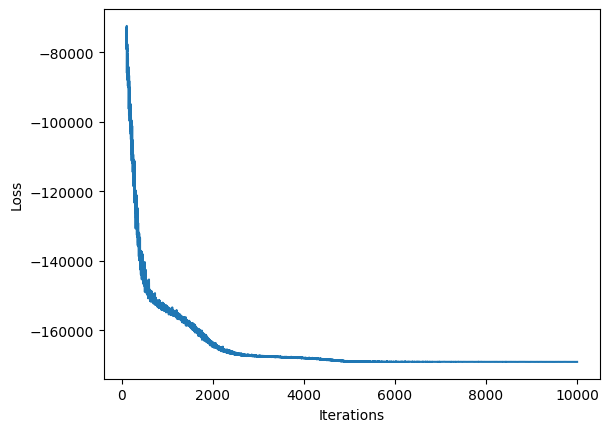

In [20]:
model.set_window(window = 100, spatial_window= 0.1)
## 100

# less interations and bigger learning rate
model.run_svi(lr=0.01,num_steps=10000)
#model.run_svi(lr=0.03,num_steps=10000)

## Results

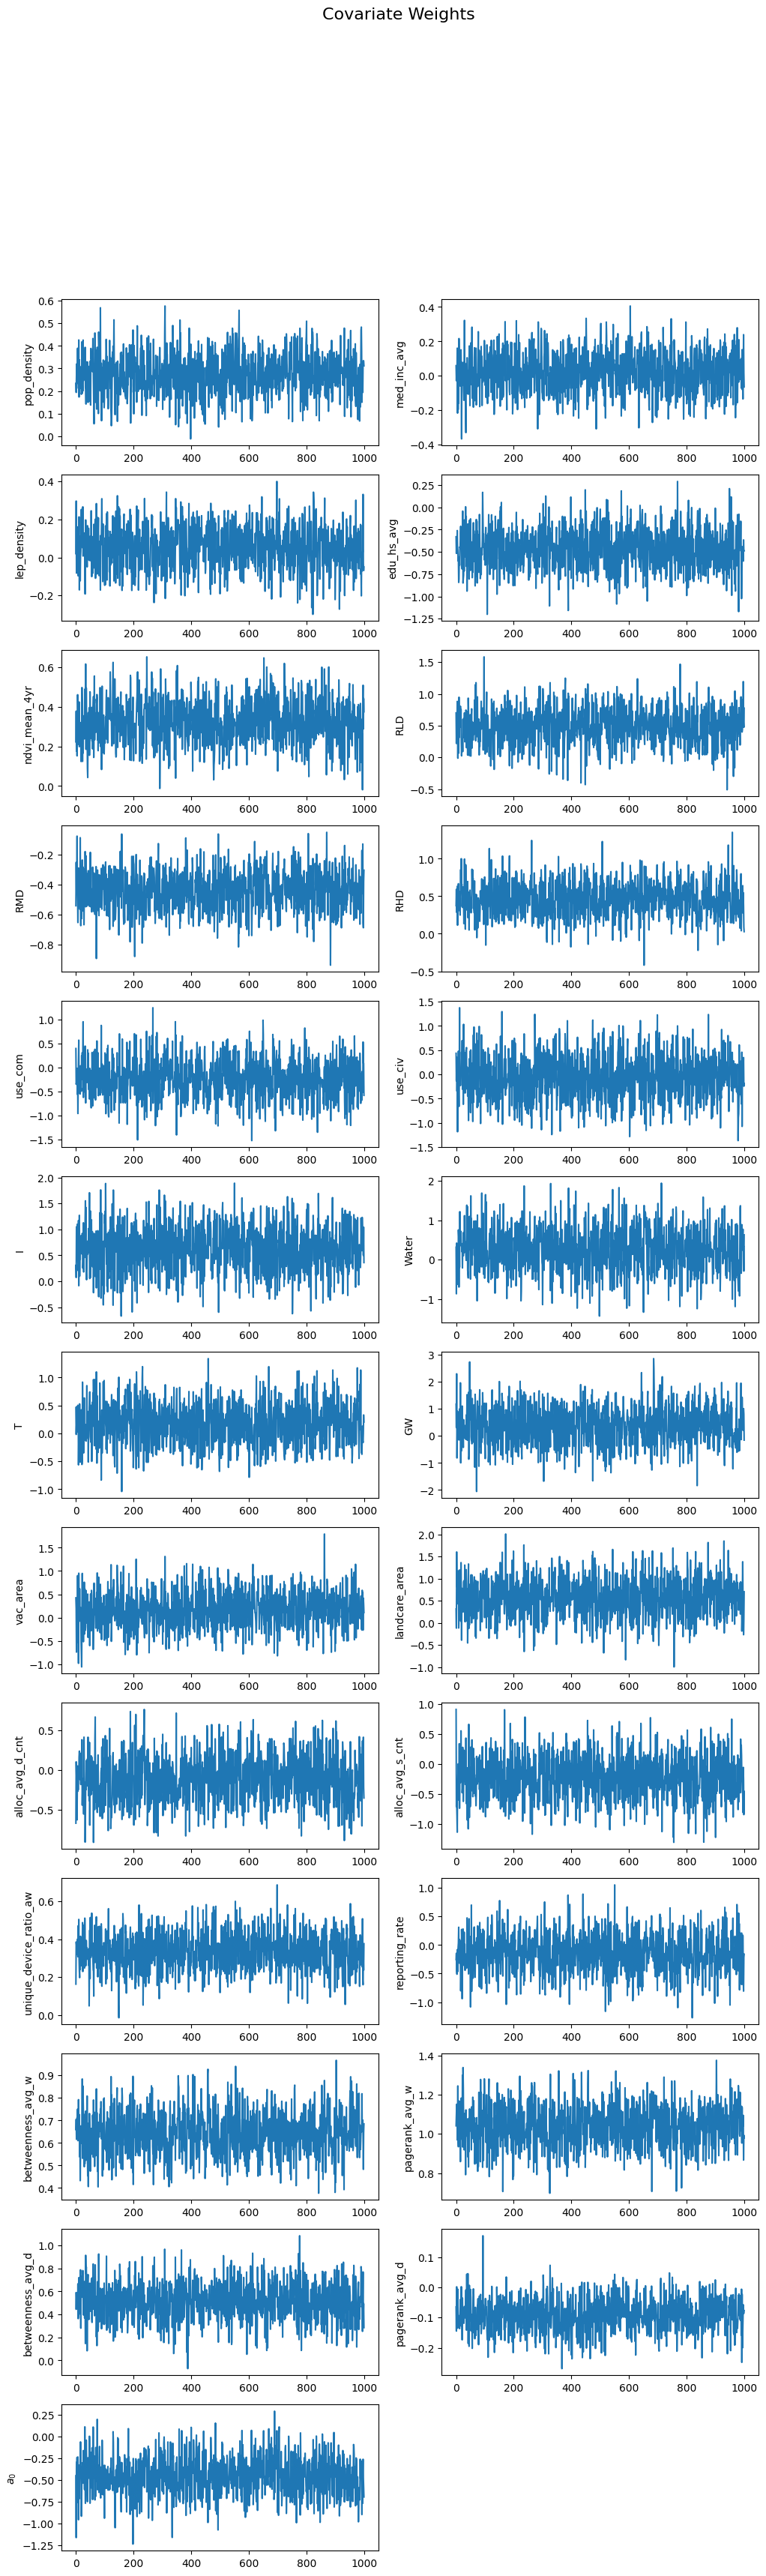

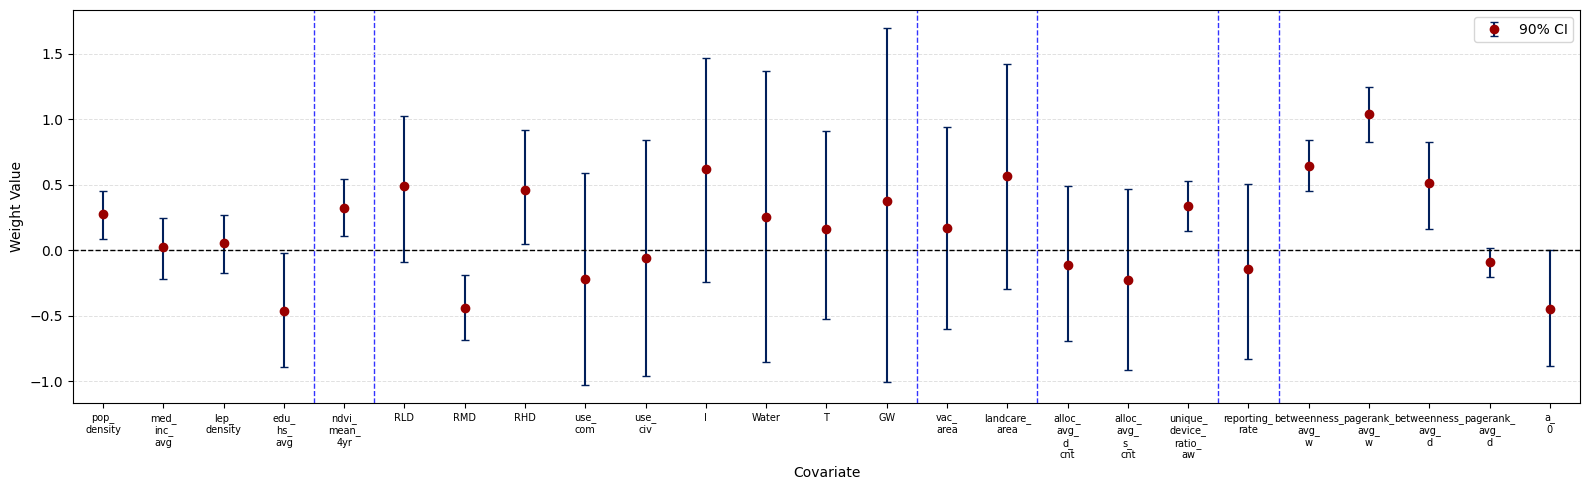

,Post Mean,Post Std,P(w>0),[0.025,0.975]
pop_density,0.273098,0.092239,0.999,0.084200,0.453882
med_inc_avg,0.020824,0.120238,0.577,-0.218803,0.243045
lep_density,0.052211,0.113283,0.680,-0.173878,0.266694
edu_hs_avg,-0.468217,0.228125,0.019,-0.889671,-0.025128
ndvi_mean_4yr,0.324458,0.110657,0.998,0.108926,0.540392
RLD,0.490132,0.286513,0.958,-0.091723,1.027992
RMD,-0.439555,0.132899,0.000,-0.685207,-0.190060
RHD,0.458560,0.230973,0.980,0.044868,0.915370
use_com,-0.222888,0.413551,0.285,-1.032596,0.589688
use_civ,-0.062983,0.463679,0.437,-0.962868,0.838920


In [43]:
model.cov_weight_post_summary(trace=True)

- Higher values indicate better model fit to the data

In [44]:
model.log_expected_likelihood(locs_s)

Final test_args keys: ['T', 'S', 't_min', 'x_min', 'x_max', 'y_min', 'y_max', 'model', 'offset_seasonal', 'A_area', 'A_', 'n_t', 'x_t', 'n_s', 'x_a', 'n_xy', 'spatial_grid_cells', 't_events', 'indices_t', 'a_events', 'indices_a', 'indices_xy', 'xy_events', 'gp_kernel', 'hidden_dim_temporal', 'z_dim_temporal', 'hidden_dim1_seasonal', 'hidden_dim2_seasonal', 'z_dim_seasonal', 'hidden_dim1_spatial', 'hidden_dim2_spatial', 'z_dim_spatial', 'decoder_params_temporal', 'decoder_params_seasonal', 'decoder_params_spatial', 'cov_ind', 'num_cov', 'spatial_cov', 'int_df', 'sp_var_mu', 'priors', 't_trig', 'sp_trig', 'window', 'spatial_window', 'coords', 't_vals', 'x_vals', 'y_vals']


23608.23046875

In [45]:
model.expected_AIC()

-44554.71875

0.5270732641220093

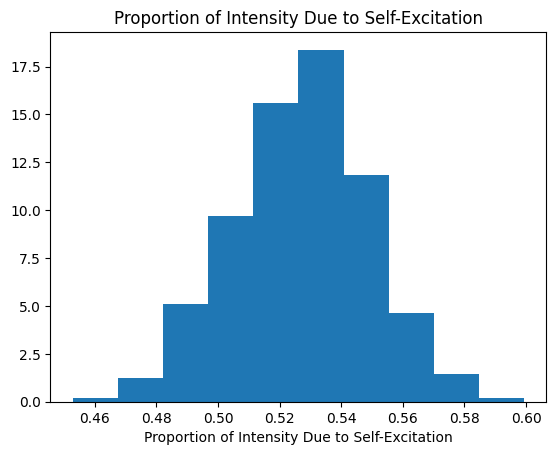

In [46]:
model.plot_prop_excitation()


In [47]:
par_names = model.args['t_trig'].get_par_names()
print(par_names)

['beta', 'gamma']


,Post Mean,Post Std,P(w>0),[0.025,0.975]
alpha,8.887052e-01,4.414629e-02,1.0,7.862154e-01,9.524848e-01
beta,2.079024e-01,1.962622e-02,1.0,1.737119e-01,2.487258e-01
gamma,2.078588e-01,2.750817e-02,1.0,1.563750e-01,2.668900e-01
sigmax_2,2.581228e-17,1.816727e-17,1.0,6.239991e-18,7.152663e-17


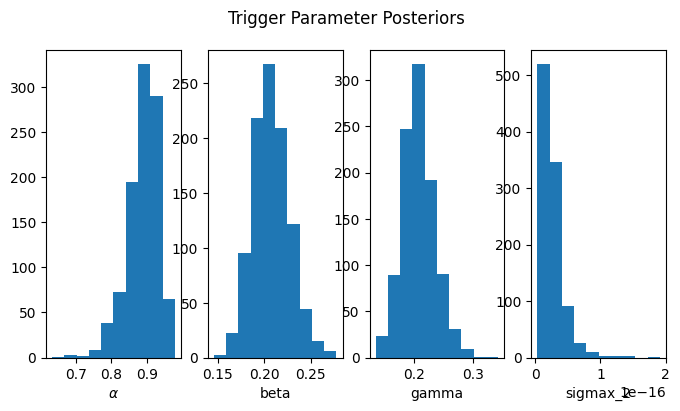

In [48]:
model.plot_trigger_posterior(trace=False)

In [49]:
# ## Spatial trigger ------------------------------------------------------
# # Step 1: Draw the original plot
# model.plot_spatial(include_cov=False)

# # Step 2: Grab the existing figure and axes
# fig = plt.gcf()
# axs = fig.get_axes()  # Usually [ax0, ax1, colorbar_ax]

# # Match limits from left subplot
# xlim = axs[0].get_xlim()
# ylim = axs[0].get_ylim()

# #philly_border.plot(ax=axs[0], edgecolor='red', facecolor='none', linewidth=2)
# all_parks_gdf.plot(ax=axs[0], edgecolor='white', facecolor='none', linewidth=2)
# philly_border.plot(ax=axs[0], edgecolor='darkgray', facecolor='none', linewidth=2)

# axs[0].set_xlim(xlim)
# axs[0].set_ylim(ylim)

# # Add overlays
# #all_boxes_gdf.plot(ax=axs[1], edgecolor='blue', facecolor='none', linewidth=2)
# philly_border.plot(ax=axs[1], edgecolor='darkgray', facecolor='none', linewidth=2)
# all_parks_gdf.plot(ax=axs[1], edgecolor='white', facecolor='none', linewidth=2)


# # Set the same limits on the right subplot
# axs[1].set_xlim(xlim)
# axs[1].set_ylim(ylim)

# # Step 3: Add a new axis to the right
# osm_ax = fig.add_axes([1, 0.1, 0.3, 0.8])  # [left, bottom, width, height]

# # Step 4: Draw the OpenStreetMap on the new axis
# osm_box = all_boxes_gdf[all_boxes_gdf['PARKNAME'] == park_name].to_crs(epsg=3857)
# philly_2023_3857 = philly_2023.to_crs(epsg=3857)
# all_parks_3857 = all_parks_gdf.to_crs(epsg=3857)
# land_use_current = land_use_current.to_crs(epsg=3857)
# land_care_21_25 = land_care_21_25.to_crs(epsg=3857)
# vacant_block = vacant_block.to_crs(epsg = 3857)

# # plot cbg and park boundary
# philly_2023_3857.plot(ax=osm_ax, edgecolor='#3f312b', facecolor='none', linewidth=1, zorder=3)
# all_parks_3857.plot(ax=osm_ax, color='none', edgecolor='black', linewidth=1, zorder=2)
# osm_box.plot(ax=osm_ax, edgecolor='black', facecolor='none', linewidth=2, zorder=1)
# #land_care_21_25.plot(ax=osm_ax, edgecolor='#ff00ff', facecolor='#00ffff', alpha=0.7,linewidth=1,zorder=4)
# #vacant_block.plot(ax=osm_ax, edgecolor='#ff00ff', facecolor='gray', alpha=0.7,linewidth=1, zorder=4)

# ## plot land use type
# land_use_current['type'] = land_use_current['type'].astype('category')
# #cmap = 'tab20b' # set qualitatitive color map
# cmap = ListedColormap(use_color)

# land_use_current[land_use_current['year'] == 2023].plot(
#     ax=osm_ax,
#     column='type',
#     cmap=cmap,
#     alpha=0.8,
#     legend=True,
#     legend_kwds={
#         'loc': 'center left',
#         'bbox_to_anchor': (1, 0.5),
#         'title': 'Land Use Type'
#     }
# )

# # Zoom to Cobbs Creek Park
# xlim = osm_box.total_bounds[[0, 2]]
# ylim = osm_box.total_bounds[[1, 3]]
# osm_ax.set_xlim(xlim)
# osm_ax.set_ylim(ylim)

# ctx.add_basemap(osm_ax, source=ctx.providers.CartoDB.Positron)
# #ctx.add_basemap(osm_ax)


# # Add the scale bar in kilometers
# scalebar = ScaleBar(
#     dx=1,  # 1 pixel = 1 meter (Web Mercator)
#     units='m',  # use kilometers
#     dimension='si-length',
#     length_fraction=0.25,
#     location='lower right',
#     scale_loc='bottom',
#     box_color='white',
#     box_alpha=0.8,
#     border_pad=0.6,
#     color='black',
#     font_properties={'size': 10}
# )
# osm_ax.add_artist(scalebar)

# # Optional: Clean up
# osm_ax.set_title("OpenStreetMap View")
# osm_ax.set_axis_off()

# plt.savefig('output/spatial_trigger_mifflin_zoning_full.png', dpi=500, bbox_inches='tight')


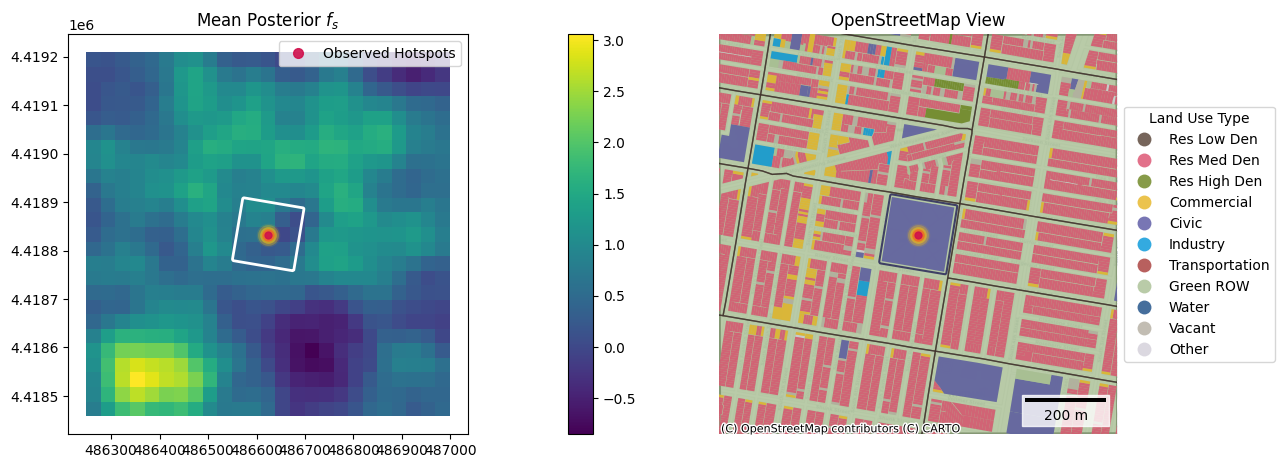

In [50]:
model.plot_spatial(include_cov=False)

# Get the current figure and axes ---------------------------------
fig = plt.gcf()
axes = fig.get_axes()

# Remove the right subplot (second axis)
fig.delaxes(axes[1])

# Match limits from left subplot
xlim = axes[0].get_xlim()
ylim = axes[0].get_ylim()

# Optionally adjust the remaining plot to use full width
axes[0].set_position([0.1, 0.1, 1, 0.8])

all_parks_gdf.plot(ax=axes[0], edgecolor='white', facecolor='none', linewidth=2)
philly_border.plot(ax=axes[0], edgecolor='darkgray', facecolor='none', linewidth=2)

# plot park hot spots
# Filter geodataframe to only points within bounds
filtered_gdf = dumping_hotspot_gdf.cx[xlim[0]:xlim[1], ylim[0]:ylim[1]]

# Extract x, y coordinates
x = filtered_gdf.geometry.x
y = filtered_gdf.geometry.y

# Plot halo
axes[0].plot(x, y, 'o', color='#FFC408',markersize=17, markeredgewidth=0,alpha=0.1)
axes[0].plot(x, y, 'o', color='#FFC408',markersize=15, markeredgewidth=0,alpha=0.3)
axes[0].plot(x, y, 'o',  color='#FFC408', markersize=12, markeredgewidth=0,alpha=0.5)
axes[0].plot(x, y, 'o', color='#F49719',markersize=9, markeredgewidth=0,alpha=0.7)

# Plot points
axes[0].plot(x, y, 'o', color='#E86A2A',markersize=8,alpha=0.7)
axes[0].plot(x, y, 'o', color='#D0104C',markersize=5,alpha=0.9)
             

axes[0].set_xlim(xlim)
axes[0].set_ylim(ylim)

legend_handle = Line2D(
    [0], [0],
    marker='o',
    linestyle='None', 
    color='#D0104C',
    markerfacecolor='#D0104C',
    markersize=7,
    alpha=0.9,
    label='Observed Hotspots'
)

axes[0].legend(
    handles=[legend_handle],
    loc='upper right'
)

axes[0].set_xlim(xlim)
axes[0].set_ylim(ylim)

# Step 3: Add a new axis to the right ---------------------------------
osm_ax = fig.add_axes([1, 0.1, 0.5, 0.8])  # [left, bottom, width, height]

# Step 4: Draw the OpenStreetMap on the new axis
osm_box = all_boxes_gdf[all_boxes_gdf['PARKNAME'] == park_name].to_crs(epsg=3857)
philly_2023_3857 = philly_2023.to_crs(epsg=3857)
all_parks_3857 = all_parks_gdf.to_crs(epsg=3857)
land_use_current = land_use_current.to_crs(epsg=3857)



# plot cbg and park boundary
philly_2023_3857.plot(ax=osm_ax, edgecolor='#3f312b', facecolor='none', linewidth=1, zorder=3, alpha = 0.7)
all_parks_3857.plot(ax=osm_ax, color='none', edgecolor='#211E55', linewidth=1.5, zorder=2, alpha = 0.8)
osm_box.plot(ax=osm_ax, edgecolor='black', facecolor='none', linewidth=2, zorder=1)


## plot land use type
land_use_current['type'] = land_use_current['type'].astype('category')
#cmap = 'tab20b' # set qualitatitive color map
cmap = ListedColormap(use_color)

land_use_current[land_use_current['year'] == 2023].plot(
    ax=osm_ax,
    column='type',
    cmap=cmap,
    alpha=0.8,
    legend=True,
    legend_kwds={
        'loc': 'center left',
        'bbox_to_anchor': (1, 0.5),
        'title': 'Land Use Type'
    }
)

# plot park hot spots
# Filter geodataframe to only points within bounds
filtered_gdf = dumping_hotspot_gdf.cx[xlim[0]:xlim[1], ylim[0]:ylim[1]]
filtered_gdf_3857 = filtered_gdf.to_crs(epsg=3857)

# Extract x, y coordinates
x = filtered_gdf_3857.geometry.x
y = filtered_gdf_3857.geometry.y

# Plot halo
osm_ax.plot(x, y, 'o', color='#FFC408',markersize=17, markeredgewidth=0,alpha=0.1)
osm_ax.plot(x, y, 'o', color='#FFC408',markersize=15, markeredgewidth=0,alpha=0.3)
osm_ax.plot(x, y, 'o',  color='#FFC408', markersize=12, markeredgewidth=0,alpha=0.5)
osm_ax.plot(x, y, 'o', color='#F49719',markersize=9, markeredgewidth=0,alpha=0.7)

# Plot points
osm_ax.plot(x, y, 'o', color='#E86A2A',markersize=8,alpha=0.7)
osm_ax.plot(x, y, 'o', color='#D0104C',markersize=5,alpha=0.9)

# Zoom to Cobbs Creek Park
xlim = osm_box.total_bounds[[0, 2]]
ylim = osm_box.total_bounds[[1, 3]]
osm_ax.set_xlim(xlim)
osm_ax.set_ylim(ylim)

ctx.add_basemap(osm_ax, source=ctx.providers.CartoDB.Positron)
#ctx.add_basemap(osm_ax)


# Add the scale bar in kilometers
scalebar = ScaleBar(
    dx=1,  # 1 pixel = 1 meter (Web Mercator)
    units='m',  # use kilometers
    dimension='si-length',
    length_fraction=0.25,
    location='lower right',
    scale_loc='bottom',
    box_color='white',
    box_alpha=0.8,
    border_pad=0.6,
    color='black',
    font_properties={'size': 10}
)
osm_ax.add_artist(scalebar)

# Optional: Clean up
osm_ax.set_title("OpenStreetMap View")
osm_ax.set_axis_off()

plt.savefig('output/ppr_hotspots_mifflin.png', dpi=500, bbox_inches='tight')

plt.show()

In [51]:
# ## Uncertainty map ------------------------------------------------------
# # Get uncertainty measures
# f_xy_samples = model.samples["f_xy"]
# f_xy_mean = np.mean(f_xy_samples, axis=0)
# f_xy_std = np.std(f_xy_samples, axis=0) # Standard deviation across samples

# # Get boundary from model.A geometry
# bounds = model.A[['geometry']].total_bounds  # [minx, miny, maxx, maxy]
# minx, miny, maxx, maxy = bounds

# # Since spatial_grid contains indices, we need to create coordinates
# # For a 625-cell grid, this is likely a 25x25 grid (25² = 625)
# grid_size = int(np.sqrt(625))  # Should be 25
# print(f"Grid size: {grid_size}x{grid_size}")

# # Create coordinate arrays based on actual geometry bounds
# x_indices = np.linspace(minx, maxx, grid_size)
# y_indices = np.linspace(miny, maxy, grid_size)
# X, Y = np.meshgrid(x_indices, y_indices)

# # Reshape your data to match the grid
# f_xy_mean_grid = f_xy_mean.reshape(grid_size, grid_size)
# f_xy_std_grid = f_xy_std.reshape(grid_size, grid_size)

# # Create the plots
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# # Mean surface
# im1 = ax1.imshow(f_xy_mean_grid, origin='lower', cmap='viridis', extent=[minx, maxx, miny, maxy])
# model.points.plot(ax=ax1,color='red',marker='x',alpha=0.1)
# all_parks_gdf.plot(ax=ax1, edgecolor='white', facecolor='none', linewidth=2)

# ax1.set_title('Mean Posterior $f_s$ With Events')
# ax1.set_xlim(minx, maxx)  # Set x limits to bounds
# ax1.set_ylim(miny, maxy)  # Set y limits to bounds
# plt.colorbar(im1, ax=ax1, shrink=0.7)

# # Uncertainty surface
# im2 = ax2.imshow(f_xy_std_grid, origin='lower', cmap='RdYlGn_r', extent=[minx, maxx, miny, maxy], vmin=0, vmax=0.33)
# all_parks_gdf.plot(ax=ax2, edgecolor='gray', facecolor='none', linewidth=2)

# ax2.set_title('$f_s$ Uncertainty (Std Dev)')
# ax2.set_xlim(minx, maxx)  # Set x limits to bounds
# ax2.set_ylim(miny, maxy)  # Set y limits to bounds
# plt.colorbar(im2, ax=ax2, shrink=0.7)

# plt.tight_layout()
# # plt.savefig('output/uncertainty_mifflin.png', dpi=500, bbox_inches='tight')
# plt.show()

# # Print some summary statistics
# print(f"Mean f_xy range: {f_xy_mean.min():.3f} to {f_xy_mean.max():.3f}")
# print(f"Std f_xy range: {f_xy_std.min():.3f} to {f_xy_std.max():.3f}")

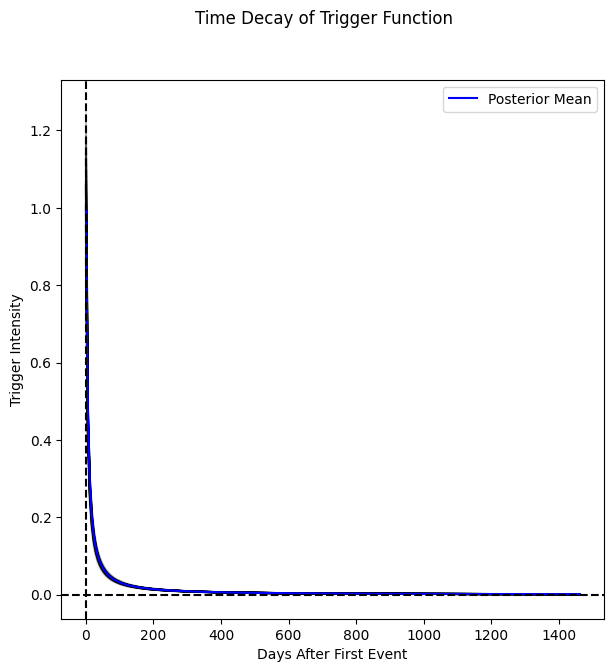

In [52]:
model.plot_trigger_time_decay()

In [53]:
# df = park_points.copy()

# # Ensure the 'start_time' column is in datetime format
# df['start_time'] = pd.to_datetime(df['start_time'])

# # Sort the DataFrame by 'address' and 'start_time'
# df.sort_values(by=['address', 'start_time'], inplace=True)

# # Group by address and get the next start time
# grouped = df.groupby('address')
# df['next_start_time'] = grouped['start_time'].shift(-1)

# # Calculate the time difference in days
# df['delta_t_days'] = (df['next_start_time'] - df['start_time']).dt.total_seconds() / (60 * 60 * 24)

# # Drop rows where the next start time is missing
# df.dropna(subset=['delta_t_days'], inplace=True)


# fig,ax = plt.subplots(figsize=(9,9))

# # Use the hist() function to plot the frequency distribution of delta_t
# ax.hist(df['delta_t_days'], bins=50, edgecolor='black', alpha=0.7, color='gray')

# # Set labels and title
# ax.set_title('Frequency Distribution of Time Difference Between Requests')
# ax.set_xlim(-50, 1500)
# ax.set_xlabel('Time Difference (days)')
# ax.set_ylabel('Frequency')
# ax.grid(axis='y', alpha=0.75)
# #plt.tight_layout()
# plt.savefig('output/decay_mifflin_full.png', dpi=500, bbox_inches='tight')
# plt.show() # This will now show the figure after it has been saved

In [54]:
# ## Delta t distribution ------------------------------------------------------
# df = park_points.copy()

# # Ensure the 'start_time' column is in datetime format
# df['start_time'] = pd.to_datetime(df['start_time'])

# # Sort the DataFrame by 'address' and 'start_time'
# df.sort_values(by=['address', 'start_time'], inplace=True)

# # Group by address and get the next start time
# grouped = df.groupby('address')
# df['next_start_time'] = grouped['start_time'].shift(-1)

# # Calculate the time difference in days
# df['delta_t_days'] = (df['next_start_time'] - df['start_time']).dt.total_seconds() / (60 * 60 * 24)

# # Drop rows where the next start time is missing
# df.dropna(subset=['delta_t_days'], inplace=True)

# # Create manual bins
# min_val = df['delta_t_days'].min()
# max_val = df['delta_t_days'].max()
# bins = np.linspace(min_val, max_val, 1200)  # 51 edges create 50 bins
# bin_centers = (bins[:-1] + bins[1:]) / 2

# # Print binning information
# num_bins = len(bins) - 1
# bin_width = (max_val - min_val) / num_bins
# actual_time_range = max_val - min_val

# print(f"Number of bins: {num_bins}")
# print(f"Bin width: {bin_width:.4f} days")
# print(f"Actual time range: {actual_time_range:.4f} days (from {min_val:.4f} to {max_val:.4f})")

# # Calculate histogram manually
# counts, _ = np.histogram(df['delta_t_days'], bins=bins)

# # Create the plot
# fig, ax = plt.subplots(figsize=(9,9))

# # Use bar plot instead of hist
# ax.bar(bin_centers, counts, width=np.diff(bins), edgecolor='black', alpha=0.7, color='gray')

# # Set labels and title
# ax.set_title('Frequency Distribution of Time Difference Between Requests',pad=30)
# ax.set_xlim(-50, 1500)
# ax.set_xlabel('Time Difference (days)')
# ax.set_ylabel('Frequency')
# ax.grid(axis='y', alpha=0.75)
# plt.tight_layout()
# #plt.savefig('output/delta_t_mifflin.png', dpi=500, bbox_inches='tight')
# plt.show() # This will now show the figure after it has been saved

In [55]:
# Get parameter names
par_names = model.args['t_trig'].get_par_names()  # ['beta', 'gamma']
params_mean = {}

# Calculate mean of posterior samples for each parameter
for name in par_names:
    params_mean[name] = model.samples[name].mean().item()

prior_value = locs_s
tpl = Temporal_Power_Law(prior_value)

# # # Step 2: Use your extracted parameters (replace params_mean with your actual variable)
# # params_from_model = params_mean  # <-- Replace this with your actual parameter variable
# params_from_model = {
#     'beta': float(params_mean['beta']),   # Convert array to scalar
#     'gamma': float(params_mean['gamma'])  # Convert array to scalar
# }

In [56]:
## Delta t distribution ------------------------------------------------------
df = park_points.copy()

# Ensure the 'start_time' column is in datetime format
df['start_time'] = pd.to_datetime(df['start_time'])

# Sort the DataFrame by 'address' and 'start_time'
df.sort_values(by=['address', 'start_time'], inplace=True)

# Group by address and get the next start time
grouped = df.groupby('address')
df['next_start_time'] = grouped['start_time'].shift(-1)

# Calculate the time difference in days
df['delta_t_days'] = (df['next_start_time'] - df['start_time']).dt.total_seconds() / (60 * 60 * 24)

# Drop rows where the next start time is missing
df.dropna(subset=['delta_t_days'], inplace=True)

# Create manual bins
min_val = df['delta_t_days'].min()
max_val = df['delta_t_days'].max()
bins = np.linspace(min_val, max_val, 1200)  # 51 edges create 50 bins
bin_centers_real = (bins[:-1] + bins[1:]) / 2

# Print binning information
num_bins = len(bins) - 1
bin_width = (max_val - min_val) / num_bins
actual_time_range = max_val - min_val

print(f"Number of bins: {num_bins}")
print(f"Bin width: {bin_width:.4f} days")
print(f"Actual time range: {actual_time_range:.4f} days (from {min_val:.4f} to {max_val:.4f})")

# Calculate histogram manually
counts, _ = np.histogram(df['delta_t_days'], bins=bins)

# # simulated delta t------------------------------------------------------------
# # set the scale for rescalring
# scale = total_days / 50  # e.g., 1460/50

# # First calculate the bin width from your data
# data_min = df['delta_t_days'].min()
# data_max = df['delta_t_days'].max()
# data_range = data_max - data_min
# bin_width = data_range / 1200

# max_time = 365 * 4  # days
# num_bins = int(max_time / bin_width)
# bin_edges = np.linspace(0, max_time, num_bins + 1) 

# print(f"Bin width: {bin_width:.1f} days")
# print(f"Number of bins: {num_bins}")
# print(f"Time range: 0 to {max_time} days")

# histogram_matrix = []

# for i in range(500):
#     samples = []
#     for j in range(locs_s.shape[0]):
#         s = tpl.simulate_trigger(params_from_model)  # already in days
#         s_days = s * scale
#         samples.append(s_days)             # clip to match bins
#     hist_counts, _ = np.histogram(samples, bins=bin_edges)
#     histogram_matrix.append(hist_counts)
#     if (i + 1) % 100 == 0:
#         print(f"Completed {i + 1}/500 iterations")

# histogram_matrix = np.array(histogram_matrix)

# column_averages = np.mean(histogram_matrix, axis=0)

# fig, ax = plt.subplots(figsize=(9,9))

# # First dataset - observed data (1199 points)
# ax.plot(bin_centers_real, counts, marker='o', linestyle='-', 
#         color='#69821b', linewidth=1.5, markersize=2, label='Observed',alpha=0.7)

# # Second dataset - simulated data (1518 points) - separate plot call
# bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# ax.plot(bin_centers, column_averages, marker='s', linestyle='-', 
#         color='#4d5aaf', linewidth=1.5, markersize=2, label='Simulated')

# # Set labels and title
# ax.set_title('Frequency Distribution of Time Difference Between Requests', pad=30)
# ax.set_xlabel('Time Difference (days)')
# ax.set_ylabel('Frequency / Count')
# ax.legend()
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

Number of bins: 1199
Bin width: 0.9625 days
Actual time range: 1153.9792 days (from 0.0000 to 1153.9792)


In [57]:
# fig, ax = plt.subplots(figsize=(9,9))

# # First dataset - observed data (1199 points)
# ax.plot(bin_centers_real, counts, marker='o', linestyle='-', 
#         color='#69821b', linewidth=1.5, markersize=2, label='Observed',alpha=0.7)

# # Second dataset - simulated data (1518 points) - separate plot call
# ax.plot(bin_centers, column_averages, marker='s', linestyle='-', 
#         color='#4d5aaf', linewidth=1.5, markersize=2, label='Simulated')

# # Set labels and title
# ax.set_title('Frequency Distribution of Time Difference Between Requests', pad=30)
# ax.set_xlabel('Time Difference (days)')
# ax.set_ylabel('Frequency / Count')
# ax.set_xlim(-10, 200)
# ax.legend()
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# # plt.savefig('output/delta_t_tacony_simulated.png', dpi=500, bbox_inches='tight')
# plt.show()

/var/folders/nr/q7sysy9j07x_5smd2gfx3j380000gn/T/ipykernel_93388/1265717719.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


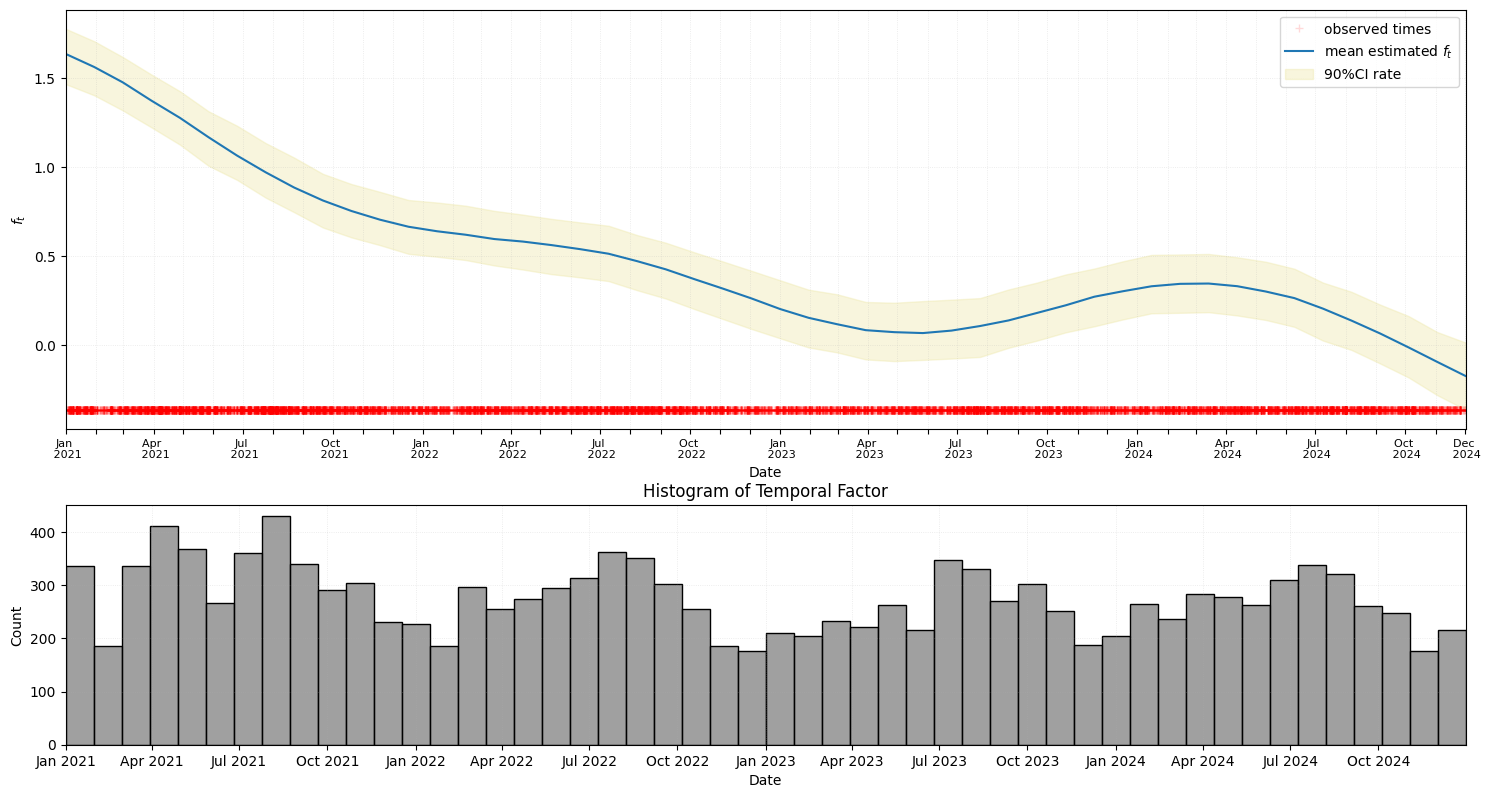

In [21]:
model.plot_temporal(start_date=min_time)

# Step 2: Grab the existing figure and axes
fig = plt.gcf()
axs = fig.get_axes()


# Plot histogram on ax2
main_ax = axs[0]
pos = main_ax.get_position()

hist_ax = fig.add_axes([pos.x0, -0.5, pos.width, 0.48])


sns.histplot(park_points['start_time'], bins=50, kde=False, ax=hist_ax, color='gray')
hist_ax.set_xlabel("Date")
hist_ax.set_ylabel("Count")
hist_ax.set_title("Histogram of Temporal Factor")
start = pd.to_datetime("2021-01-01") - pd.Timedelta(days=0)
end = pd.to_datetime("2024-12-31") + pd.Timedelta(days=0)
hist_ax.set_xlim(start, end)
hist_ax.margins(x=0)
hist_ax.grid(True, which='both', axis='both', linestyle=':', linewidth=0.6, alpha=0.3)

#hist_ax.xaxis.set_major_locator(plt.MaxNLocator(10))
hist_ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=3)
)
hist_ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y')
)

plt.tight_layout()
#plt.savefig('output/temp_mifflin_full.png', dpi=500, bbox_inches='tight')
plt.show()

/Users/yuxin/BSTPP/bstpp/main.py:841: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/nr/q7sysy9j07x_5smd2gfx3j380000gn/T/ipykernel_93388/705358449.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


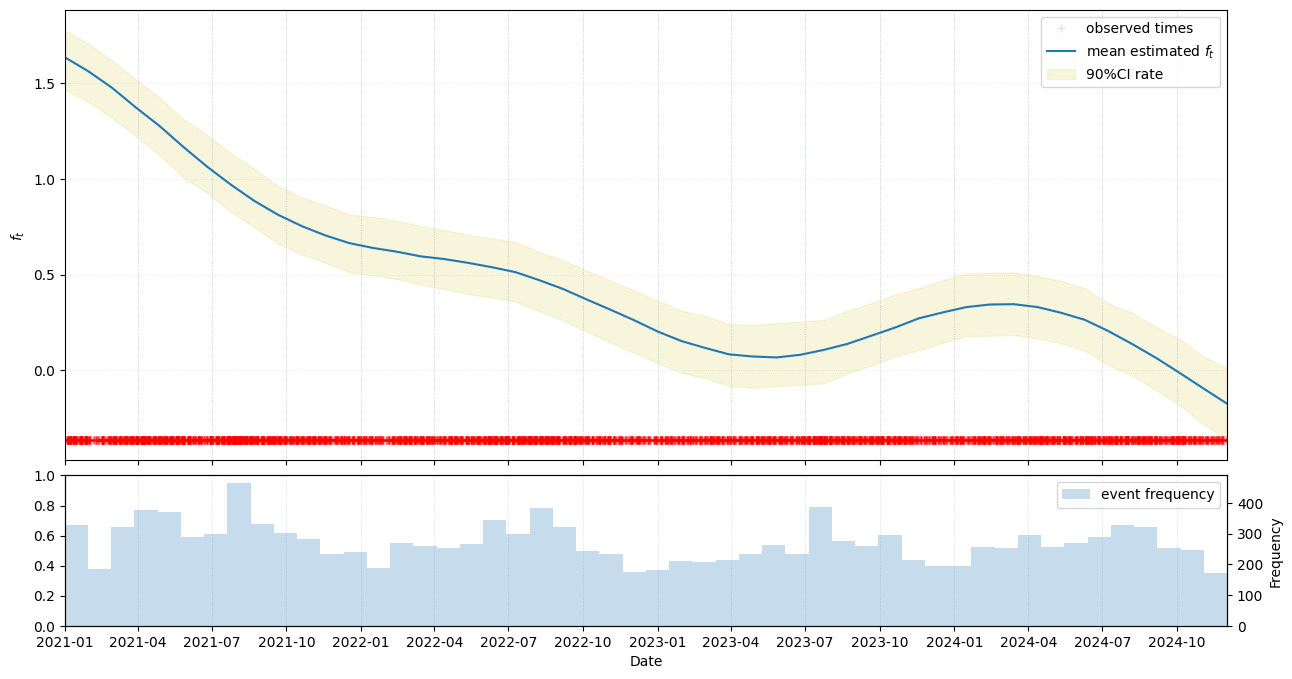

In [22]:
start_date = datetime(2021, 1, 1)  # <-- change this to your real start date

fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    figsize=(15, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# Top: GP only
model.plot_temporal_components(
    rescale=True,
    start_date=None,     # IMPORTANT: don't try to do date formatting inside the method
    show_gp=True,
    show_hist=False,
    ax=ax_top
)
ax_top.tick_params(labelbottom=False)
ax_top.set_xlabel("")

# Bottom: histogram only
model.plot_temporal_components(
    rescale=True,
    start_date=None,     # IMPORTANT: we'll format dates ourselves below
    show_gp=False,
    show_hist=True,
    ax=ax_bottom
)

# ----------------------------
# 3) Add calendar month ticks to the SHARED x-axis (bottom axis renders labels)
#    Assumes x-axis is "t in days" starting from start_date
# ----------------------------
x0, x1 = ax_bottom.get_xlim()
x_max = int(np.ceil(x1))

end_date = start_date + pd.Timedelta(days=x_max)

month_starts = pd.date_range(start=start_date, end=end_date, freq="MS")
label_every_n_months = 3
month_starts_labeled = month_starts[::label_every_n_months]

xticks = [(d.to_pydatetime() - start_date).days for d in month_starts_labeled]
xlabels = [d.strftime("%Y-%m") for d in month_starts_labeled]

ax_bottom.set_xticks(xticks)
ax_bottom.set_xticklabels(xlabels)
ax_bottom.set_xlabel("Date")

# Optional: add vertical month gridlines on BOTH panels for alignment
for ax in (ax_top, ax_bottom):
    for d in month_starts_labeled:
        x = (d.to_pydatetime() - start_date).days
        ax.axvline(x, linestyle=":", linewidth=0.6, alpha=0.25)

plt.tight_layout()
plt.show()

In [60]:
def simulate_triggers_histogram(beta, gamma, df, locs_s, tpl, scale, 
                                max_time=365*4, num_bins=1200, n_iterations=500):
    """
    Simulate trigger times and generate histogram for given beta and gamma parameters.
    """
    # First calculate the bin width from your data
    data_min = df['delta_t_days'].min()
    data_max = df['delta_t_days'].max()
    data_range = data_max - data_min
    bin_width = data_range / num_bins
    
    # Create bin edges
    num_bins_calc = int(max_time / bin_width)
    bin_edges = np.linspace(0, max_time, num_bins_calc + 1)
    
    # Set up parameters
    params_from_model = {
        'beta': float(beta),
        'gamma': float(gamma)
    }
    
    histogram_matrix = []
    
    for i in range(n_iterations):
        samples = []
        for j in range(locs_s.shape[0]):
            s = tpl.simulate_trigger(params_from_model)
            s_days = s * scale
            samples.append(s_days)
        
        hist_counts, _ = np.histogram(samples, bins=bin_edges)
        histogram_matrix.append(hist_counts)
    
    histogram_matrix = np.array(histogram_matrix)
    column_averages = np.mean(histogram_matrix, axis=0)
    
    return bin_edges, column_averages


def run_posterior_simulations(model, df, locs_s, tpl, scale, 
                              n_posterior_samples=100, **kwargs):
    """
    Run simulations using posterior samples of beta and gamma.
    """
    # Extract parameter names
    par_names = model.args['t_trig'].get_par_names()
    
    # Get total number of posterior samples
    n_samples = len(model.samples[par_names[0]])
    
    # Randomly sample indices
    indices = np.random.choice(n_samples, size=n_posterior_samples, replace=False) # 
    
    all_histograms = []
    
    print(f"\n{'='*70}")
    print(f"Starting posterior simulations with {n_posterior_samples} parameter samples")
    print(f"{'='*70}\n")
    
    # Use tqdm.notebook for Jupyter - it has a nice widget-based progress bar
    pbar = tqdm(total=n_posterior_samples, desc="Overall Progress")
    
    for idx, i in enumerate(indices):
        # Extract beta and gamma for this iteration
        beta = float(model.samples['beta'][i])
        gamma = float(model.samples['gamma'][i])
        
        # Print posterior sample info
        print(f"Posterior sample {idx + 1}/{n_posterior_samples}: beta={beta:.4f}, gamma={gamma:.4f}")
        
        # Run simulation with these parameters
        bin_edges, column_avg = simulate_triggers_histogram(
            beta, gamma, df, locs_s, tpl, scale,
            **kwargs
        )
        
        all_histograms.append(column_avg)
        
        # Update progress bar
        pbar.update(1)
    
    pbar.close()
    
    print(f"\n{'='*70}")
    print("✓ All posterior simulations completed!")
    print(f"{'='*70}\n")
    
    # Convert to array and calculate statistics
    all_histograms = np.array(all_histograms)
    
    print("Calculating statistics across all posterior samples...")
    mean_counts = np.mean(all_histograms, axis=0)
    lower_bound = np.percentile(all_histograms, 2.5, axis=0)
    upper_bound = np.percentile(all_histograms, 97.5, axis=0)
    
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    
    return bin_centers, mean_counts, lower_bound, upper_bound, all_histograms

In [61]:
# # Usage:
# scale = total_days / 50  # Your existing scale

# # Run with posterior uncertainty
# bin_centers, mean_counts, lower_bound, upper_bound, all_histograms = run_posterior_simulations(
#     model=model,
#     df=df,
#     locs_s=locs_s,
#     tpl=tpl,
#     scale=scale,
#     n_posterior_samples=100,  # Adjust based on computational budget
#     max_time=365*4,
#     num_bins=1200,
#     n_iterations=500
# )

# # Plot results
# fig, ax = plt.subplots(figsize=(12, 8))

# # plot observed data
# ax.plot(bin_centers_real, counts, marker='o', linestyle='-', 
#         color='#69821b', linewidth=1.5, markersize=2, label='Observed',alpha=0.7)

# # Plot mean line
# ax.plot(bin_centers, mean_counts, color='blue', linewidth=1, label='Simulated (Mean)')

# # Plot uncertainty band
# ax.fill_between(bin_centers, lower_bound, upper_bound, 
#                 color='#4d5aaf', alpha=0.3, label='95% Confidence Interval')

# # If you have observed data, plot it too
# # ax.bar(observed_bins, observed_counts, alpha=0.7, color='green', 
# #        label='Observed', width=bin_width*0.8)

# ax.set_xlabel('Time Difference (days)', fontsize=12)
# ax.set_ylabel('Count', fontsize=12)
# ax.set_title('Trigger Simulation with Posterior Uncertainty', fontsize=14)
# ax.set_xlim(-10, 200)
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig('output/delta_t_tacony_simulated.png', dpi=500, bbox_inches='tight')
# plt.show()

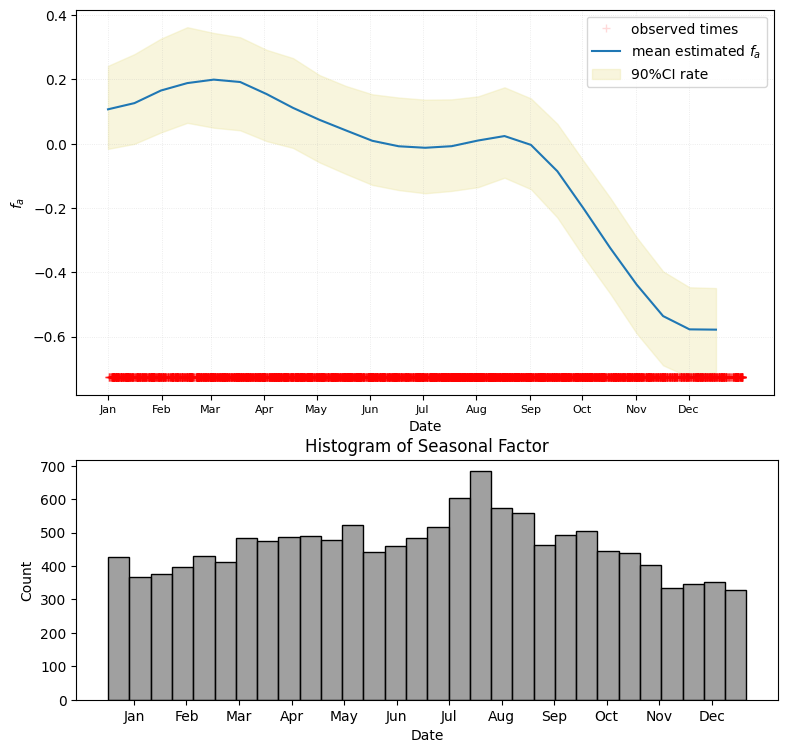

In [23]:
model.plot_seasonal()

# Step 2: Grab the existing figure and axes
fig = plt.gcf()
axs = fig.get_axes()

# Plot histogram on ax2
hist_ax = fig.add_axes([0.125, -0.5, 0.78, 0.48])  # [left, bottom, width, height]

sns.histplot(locs_s['A'], bins=30, kde=False, ax=hist_ax, color='gray')
hist_ax.set_xlabel("Date")
hist_ax.set_ylabel("Count")
hist_ax.set_title("Histogram of Seasonal Factor")
# Format x-axis as Jan, Feb, etc.
month_locs = [15 + i*30 for i in range(12)]  # rough midpoints for months
month_labels = [calendar.month_abbr[i+1] for i in range(12)]

hist_ax.set_xticks(month_locs)
hist_ax.set_xticklabels(month_labels)
#plt.savefig('output/seasonal_mifflin_full.png', dpi=500, bbox_inches='tight')
plt.show()

In [63]:
# # First calculate the bin width from your data
# data_min = df['delta_t_days'].min()
# data_max = df['delta_t_days'].max()
# data_range = data_max - data_min
# bin_width = data_range / 1200  # From your bins=50 in the histogram

# max_time = 365 * 4  # 4 years in days
# num_bins = int(max_time / bin_width)  # Calculate number of bins based on your bin width
# bin_edges = np.linspace(0, max_time, num_bins + 1)

# print(f"Bin width: {bin_width:.1f} days")
# print(f"Number of bins: {num_bins}")
# print(f"Time range: 0 to {max_time} days")

# # store histogram for each iteration
# histogram_matrix = []

# for i in range(500):
#     samples = []
#     for j in range(locs_s.shape[0]):
#         sample = tpl.simulate_trigger(params_from_model)
#         samples.append(sample / (24*60*60))

#     hist_counts, _ = np.histogram(samples, bins=bin_edges)
#     histogram_matrix.append(hist_counts)

#     if (i + 1) % 100 == 0:
#         print(f"Completed {i + 1}/1000 iterations")

# histogram_matrix = np.array(histogram_matrix)


# print(f"\nHistogram matrix shape: {histogram_matrix.shape}")
# print(f"Rows (iterations): {histogram_matrix.shape[0]}")
# print(f"Columns (time bins): {histogram_matrix.shape[1]}")


# # Calculate column averages (average across iterations for each time bin)
# column_averages = np.mean(histogram_matrix, axis=0)

# # Plot average counts per time bin
# plt.figure(figsize=(6, 6))
# bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# plt.bar(bin_centers, column_averages, width=bin_width*0.8, alpha=0.7, edgecolor='black')
# plt.xlabel('Time (days)')
# plt.ylabel('Average Count')
# plt.xlim(-50, 1500)
# plt.title(f'Average Sample Counts per Time Bin\n({histogram_matrix.shape[0]} iterations, bin width: {bin_width:.1f} days)')
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

# print(f"\nColumn averages statistics:")
# print(f"Mean of bin averages: {np.mean(column_averages):.2f}")
# print(f"Std of bin averages: {np.std(column_averages):.2f}")
# print(f"Expected average per bin: {locs_s.shape[0] / num_bins:.2f}")


In [64]:
# ## set the scale for rescalring
# scale = total_days / 50  # e.g., 1460/50

# # First calculate the bin width from your data
# data_min = df['delta_t_days'].min()
# data_max = df['delta_t_days'].max()
# data_range = data_max - data_min
# bin_width = data_range / 1200

# max_time = 365 * 4  # days
# num_bins = int(max_time / bin_width)
# bin_edges = np.linspace(0, max_time, num_bins + 1) 

# print(f"Bin width: {bin_width:.1f} days")
# print(f"Number of bins: {num_bins}")
# print(f"Time range: 0 to {max_time} days")

# histogram_matrix = []

# for i in range(500):
#     samples = []
#     for j in range(locs_s.shape[0]):
#         s = tpl.simulate_trigger(params_from_model)  # already in days
#         s_days = s * scale
#         samples.append(s_days)             # clip to match bins
#     hist_counts, _ = np.histogram(samples, bins=bin_edges)
#     histogram_matrix.append(hist_counts)
#     if (i + 1) % 100 == 0:
#         print(f"Completed {i + 1}/500 iterations")

# histogram_matrix = np.array(histogram_matrix)

# column_averages = np.mean(histogram_matrix, axis=0)

# plt.figure(figsize=(6, 6))
# bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# plt.bar(bin_centers, column_averages, width=np.diff(bin_edges)*0.8, alpha=0.7, edgecolor='black')

# plt.xlabel('Time (days)')
# plt.ylabel('Average Count')
# plt.xlim(-50, 1500)
# #plt.ylim(0, 100)
# plt.title(f'Average Sample Counts per Time Bin\n({histogram_matrix.shape[0]} iterations, bin width: {bin_width:.1f} days)')
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

# print(f"\nColumn averages statistics:")
# print(f"Mean of bin averages: {np.mean(column_averages):.2f}")
# print(f"Std of bin averages: {np.std(column_averages):.2f}")

In [65]:
# # Store histogram for each iteration
# samples_matrix = []

# # Do 1500 iterations
# for i in range(500):
#     # Sample locs_s.shape[0] times in this iteration
#     samples = []
#     for j in range(locs_s.shape[0]):
#         sample = tpl.simulate_trigger(params_from_model)
#         samples.append(sample/(24*60*60))  #  convert to days
    
#     # Create histogram for this iteration
#     samples_matrix.append(samples)

#     if (i + 1) % 100 == 0:
#         print(f"Completed {i + 1}/500 iterations")

# # Convert to numpy array: shape will be (500, 50)
# samples_matrix = np.array(samples_matrix)

# print(f"\nHistogram matrix shape: {samples_matrix.shape}")
# print(f"Rows (iterations): {samples_matrix.shape[0]}")
# print(f"Columns (time bins): {samples_matrix.shape[1]}")

In [66]:
# column_means = np.mean(samples_matrix, axis=0)
# print(f"Shape of column means: {column_means.shape}")
# print(f"First 10 column means: {column_means[:10]}")

# column_means = np.sort(column_means)

# # Step 2: Calculate delta_t between consecutive columns
# # This represents the change in mean values between adjacent time bins
# delta_t_simulated = np.diff(column_means)
# print(f"Shape of delta_t: {delta_t_simulated.shape}")
# print(f"First 10 delta_t values: {delta_t_simulated[:10]}")

# # Step 3: Extract max, min, and range for the delta_t values
# min_delta = np.min(delta_t_simulated)
# max_delta = np.max(delta_t_simulated)
# delta_range = max_delta - min_delta

# print(f"Delta_t statistics:")
# print(f"Min delta_t: {min_delta:.4f}")
# print(f"Max delta_t: {max_delta:.4f}")
# print(f"Range: {delta_range:.4f}")

# # Step 4: Create bin edges for delta_t distribution (50 bins)
# bins = np.linspace(min_delta, max_delta, 51)  # 51 edges create 50 bins
# bin_centers = (bins[:-1] + bins[1:]) / 2
# bin_width = (max_delta - min_delta) / 50

# print(f"Number of bins: 50")
# print(f"Bin width: {bin_width:.4f} days")
# print(f"Actual range: {delta_range:.4f} days (from {min_delta:.4f} to {max_delta:.4f})")

# # Check for problematic values

# print("--------------------------------")
# print("Column means stats:")
# print(f"Min: {np.min(column_means)}")
# print(f"Max: {np.max(column_means)}")
# print(f"Any NaN?: {np.any(np.isnan(column_means))}")
# print(f"Any Inf?: {np.any(np.isinf(column_means))}")

# # Check the original matrix
# print("Samples matrix stats:")
# print(f"Min: {np.min(samples_matrix)}")
# print(f"Max: {np.max(samples_matrix)}")
# print(f"Any NaN?: {np.any(np.isnan(samples_matrix))}")
